<center><h1><font color='darkblue'>Elektrotehnički fakultet Beograd</font></h1></center>

# Modeli u ekonomiji

## Luka Puco 24/0091

<font color='red'>
Preimenovati svesku: File/Rename u [3] ekonomija_ime_prezime<br>
Redovno snimati aktuelnu verziju sveske: File/Save and Checkpoint <br>
Preuzimanje fajla: Download as Notebook (.ipynb)</font>

#### __Zadatak 1__: Dinamički model
Za malu porodičnu piceriju funkcije ponude i potražnje su linearne funkcije cene: $Q_d(P) = A - BP$ i $Q_s(P) = -C + DP$, gde je $A = 22$ pice po danu, $B = 2$ pice po danu po evru, $C = 5$ pica po danu, $D = 7$ pica po danu po evru.

a) Formirati Python skriptu koja prema algoritmu sa slajdova, za definisane funkcije ponude i potražnje pronalazi stacionarno stanje $P_{eq}$. Na istom grafiku nacrtati funkcije $Q_d(P)$ i  $Q_s(P)$. Označiti ose grafika. 

Text(0, 0.5, 'potraznja')

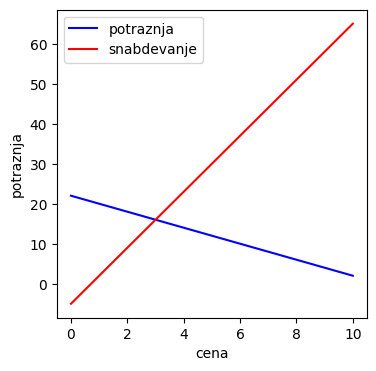

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
A,B,C,D=22,2,5,7
P=np.linspace(0,10,1000)
Qd=A-B*P
Qs=-C+D*P
plt.figure(figsize=(4,4))
plt.plot(P,Qd,label='potraznja',color='blue')
plt.plot(P,Qs,label='snabdevanje',color='red')
plt.legend()
plt.xlabel("cena")
plt.ylabel("potraznja")

b) Formirati Python definiciju (<font color='blue'>dinamicki_model</font>) koja predstavlja odgovarajuću diferencijalnu jednačinu kojom je opisana dinamika cene. Dinamika cene opisana je trenutnom razlikom između funkcije ponude i potražnje kao:

<br>
\begin{equation}
    \frac{dP(t)}{dt} = \gamma(Q_d(P) - Q_s(P)) = -\gamma(B + D)P(t) + \gamma(A + C)
\end{equation}
<br>

gde je faktor korelacije $\gamma = 0.1$ u odgovarajućim jedinicama. 
Koeficijenti $A$, $B$, $C$, $D$ i $\gamma$ treba da budu pozivni parametri definicije koja predstavlja diferencijalnu jednačinu.

In [6]:

def rhs(t, P):
    return gamma * ((A + C) - (B + D) * P)
gamma=0.1


c) Formirati Python skriptu koja rešava diferencijalnu jednačinu i iscrtava njena rešenja. Na istom grafiku prikazati dinamiku cene za tri moguća slučaja: početna cena $P(0)$ jednaka je ravnotežnoj ceni ($P(0) = P_{eq}$), početna cena je veća od ravnotežne ($P(0) = 2P_{eq}$) i početna cena je manja od ravnotežne cene ($P(0) = 0.5P_{eq}$). Za definisane parametre i početne uslove, rešavati diferencijalnu jednačinu na vremenskom domenu od $0$ do $10$ dana u $1000$ ekvidistantnih tačaka. Na istom grafiku, različitim bojama (plavom, crvenom i zelenom), nacrtati profile $P(t)$ za sva tri slučaja početnih uslova. Označiti ose grafika i ubaciti legendu.

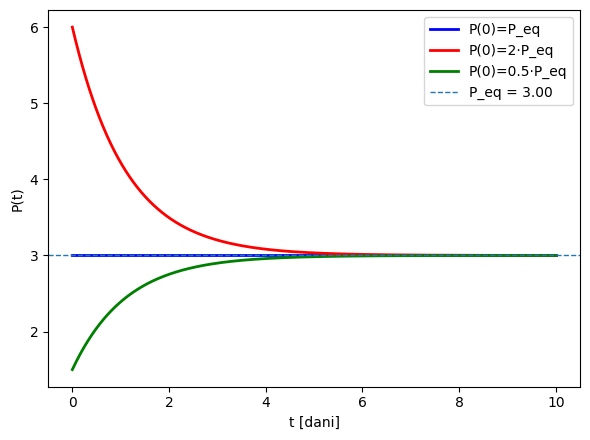

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate

A, B, C, D = 22, 2, 5, 7
gamma = 0.1

def f(P):
    return (A - B*P) - (-C + D*P)

P_scan = np.linspace(0.0, 10.0, 1001)
s = np.sign(f(P_scan))
idx = np.where(np.diff(s) != 0)[0]
P0 = P_scan[idx[0]]

def rhs(P, t, A, B, C, D, gamma):
    return gamma * ((A + C) - (B + D) * P)

t = np.linspace(0.0, 10.0, 1000)

Peq = integrate.odeint(rhs, P0, t, args=(A, B, C, D, gamma)).ravel()[-1]

cases = [("P(0)=P_eq", Peq, "blue"),
         ("P(0)=2·P_eq", 2*Peq, "red"),
         ("P(0)=0.5·P_eq", 0.5*Peq, "green")]

plt.figure(figsize=(6,4.5))
for lbl, Pinit, col in cases:
    sol = integrate.odeint(rhs, Pinit, t, args=(A, B, C, D, gamma)).ravel()
    plt.plot(t, sol, label=lbl, color=col, lw=2)

plt.axhline(Peq, ls="--", lw=1, label=f"P_eq = {Peq:.2f}")
plt.xlabel("t [dani]"); plt.ylabel("P(t)")
plt.legend(); plt.tight_layout(); plt.show()


d) Da li sistem ima stabilnu dinamiku? Šta se dešava sa cenom posle dovoljno dugog vremena? Da li se dostiže predviđeno stacionarno stanje? 

Sistem ima stabilnu dinamiku i dostize stacionarno stanje nakon odredjenog vremena cena se svede na 3.

<font color='red'>Snimiti aktuelnu verziju sveske: File/Save and Checkpoint</font>

#### __Zadatak 2__: Model sa očekivanjima cena

a) Na primeru porodične picerije sa slajdova primeniti kompleksniji model koji uključuje modelovanje očekivanja cene od strane potraživača. U takvom modelu funkcija potražnje $Q_d$ zavisi i od promene cene, kao i od brzine njene promene:

<br>
\begin{equation}
    Q_d = A - BP + M\frac{dP}{dt} + N\frac{d^2P}{dt^2},\\
    Q_s = -C + DP.
\end{equation}
<br>

Diferencijalna jednačina koja opisuje promenu cene proizvoda u ovakvom modelu i koju treba rešavati dobija se izjednačavanjem $Q_d = Q_s$ i ima formu:

<br>
\begin{equation}
    \frac{d^2P}{dt} + \frac{M}{N}\frac{dP}{dt} - \frac{B+D}{N}P = -\frac{A+C}{N}.
\end{equation}
<br>


Formirati Python definiciju (<font color='blue'>ocekivanja_cene</font>) koja predstavlja odgovarajuću diferencijalnu jednačinu kojom je opisana dinamika cene. Koeficijenti $A$, $B$, $C$, $D$, $M$ i $N$ treba da budu pozivni parametri definicije koja predstavlja diferencijalnu jednačinu.

In [10]:
def ocekivanja_cene(t, y, A, B, C, D, M, N):

    P, V = y
    dPdt = V
    dVdt = -(M/N)*V + ((B + D)/N)*P - (A + C)/N
    return [dPdt, dVdt]


b) Ispitati i diskutovati dinamiku sistema za slučaj sledećih parametara:
<ol>
<li>$A = 42$ pice po danu, $B = 4$ pice po danu po evru, $C = 6$ pica po danu, $D = 8$ pica po danu po evru, $M = –4$ pice po evru, $N = 1$ (u odgovarajućim jedinicama), $P(0) = 6$ evra, $dP/dt(0) = 4$ evra po danu. Rešavati na vremenskom domenu od $0$ do $20$ dana u $1000$ ekvidistantnih tačaka.</li> 
<br>    
    
<li>$A = 40$ pica po danu, $B = 2$ pice po danu po evru, $C = 5$ pica po danu, $D = 3$ pice po danu po evru, $M = –2$ pice po evru, $N = –1$ (u odgovarajućim jedinicama), $P(0) = 12$ evra, $dP/dt(0) = 1$ evro po danu. Rešavati na vremenskom domenu od $0$ do $20$ dana u $1000$ ekvidistantnih tačaka.</li>
<br> 

<li>$A = 40$ pica po danu, $B = 2$ pice po danu po evru, $C = 5$ pica po danu, $D = 3$ pice po danu po evru, $M = 0.5$ pice po evru, $N = –1$ (u odgovarajućim jedinicama), $P(0) = 12$ evra, $dP/dt(0) = 1$ evro po danu. Rešavati na vremenskom domenu od $0$ do $20$ dana u $1000$ ekvidistantnih tačaka.</li>
</ol>
Za svaki od tri slučaja na jednom subplot-u nacrtati i vremenski ($P$ u funkciji od $t$) i fazni dijagram ($dP/dt$ u funkciji od $P$) dinamike cene.  

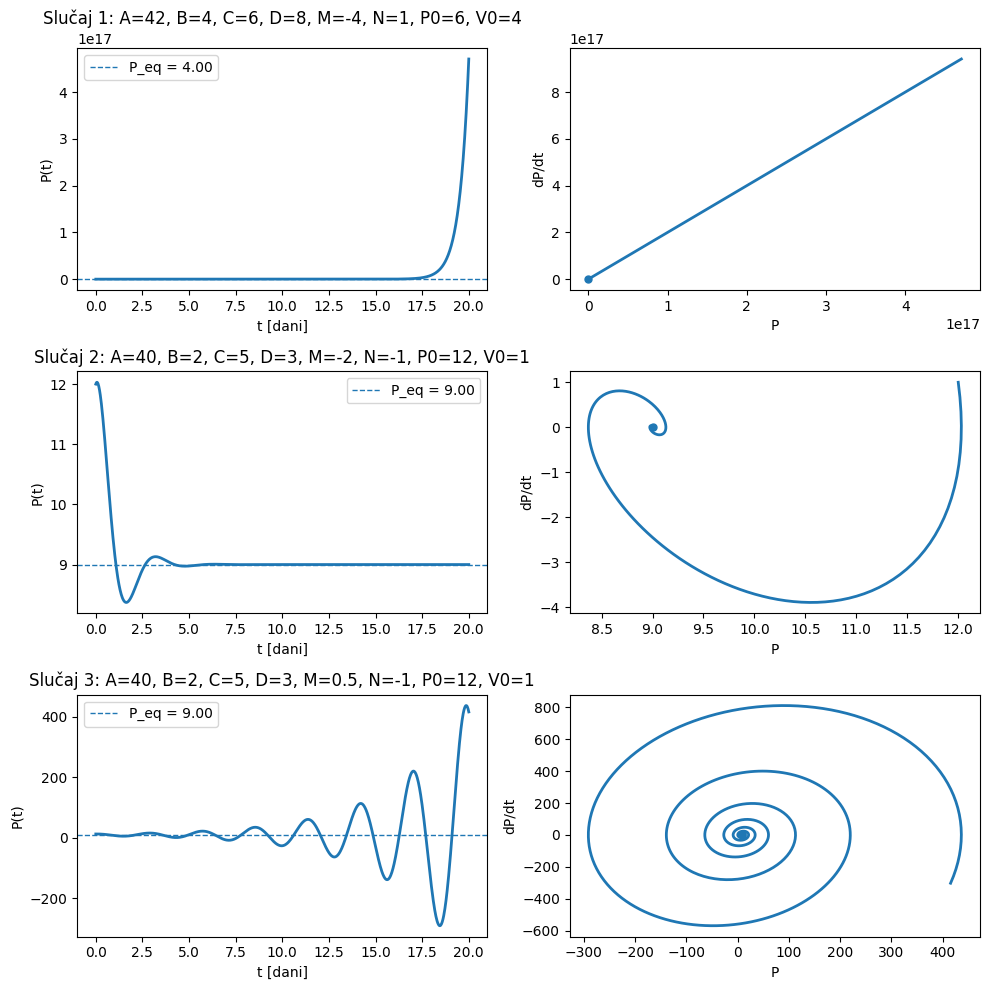

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint


def solve_and_plot(ax_t, ax_ph, title, A,B,C,D,M,N, P0, V0, t0=0, t1=20, n=1000):
    t_eval = np.linspace(t0, t1, n)

    def rhs(state, t, A,B,C,D,M,N):
        P, V = state
        Qd = A - B*P
        Qs = -C + D*P
        return [V, M*V - N*(Qd - Qs)]

    sol = odeint(rhs, [P0, V0], t_eval, args=(A,B,C,D,M,N))
    P, V = sol[:,0], sol[:,1]
    Peq = (A + C) / (B + D)

    ax_t.plot(t_eval, P, lw=2)
    ax_t.axhline(Peq, ls='--', lw=1, label=f"P_eq = {Peq:.2f}")
    ax_t.set_xlabel("t [dani]")
    ax_t.set_ylabel("P(t)")
    ax_t.set_title(title)
    ax_t.legend()

    ax_ph.plot(P, V, lw=2)
    ax_ph.scatter([Peq], [0], s=25)
    ax_ph.set_xlabel("P")
    ax_ph.set_ylabel("dP/dt")

    a = M/N
    b = -(B + D)/N

fig, axes = plt.subplots(3, 2, figsize=(10, 10))
solve_and_plot(axes[0,0], axes[0,1],
               "Slucaj 1: A=42, B=4, C=6, D=8, M=-4, N=1, P0=6, V0=4",
               42,4,6,8, -4,1, P0=6, V0=4)
solve_and_plot(axes[1,0], axes[1,1],
               "Slucaj 2: A=40, B=2, C=5, D=3, M=-2, N=-1, P0=12, V0=1",
               40,2,5,3, -2,-1, P0=12, V0=1)
solve_and_plot(axes[2,0], axes[2,1],
               "Slucaj 3: A=40, B=2, C=5, D=3, M=0.5, N=-1, P0=12, V0=1",
               40,2,5,3, 0.5,-1, P0=12, V0=1)

plt.tight_layout()
plt.show()


c) Na osnovu analize stabilnosti sa slajdova, komentarisati očekivane rezultate dinamike sa dobijenim graficima. 
U kom slučaju je dinamika stabilna, u kom nestabilna i zašto? 
Komentarisati fazne dijagrame. Kojoj vrsti oscilacija odgovara ovakav model? 
Šta bi, prema analogiji sa fizikom, bio poželjan slučaj za dinamiku cene? Predložiti neke vrednosti za parametre $B$, $D$, $M$ i $N$ tako da dinamika cene uspostavi stacionarno stanje u kratkom vremenskom periodu. Nacrtati grafik takve dinamike cene.

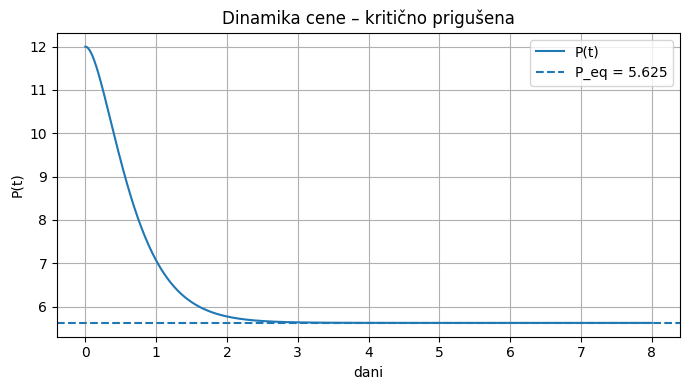

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

A, B, C, D = 40.0, 3.0, 5.0, 5.0
N = -1.0
omega_n = np.sqrt(-N*(B + D))
M = -2.0 * omega_n

Peq = (A + C) / (B + D)

def rhs(state, t, A, B, C, D, M, N):
    P, V = state
    Qd = A - B*P
    Qs = -C + D*P
    return [V, M*V - N*(Qd - Qs)]

t = np.linspace(0.0, 8.0, 800)
P0, V0 = 12.0, 0.0
sol = odeint(rhs, [P0, V0], t, args=(A, B, C, D, M, N))

plt.figure(figsize=(7,4))
plt.plot(t, sol[:, 0], label="P(t)")
plt.axhline(Peq, linestyle="--", label=f"P_eq = {Peq:.3f}")
plt.xlabel("dani"); plt.ylabel("P(t)")
plt.title("Dinamika cene – kritično prigušena")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()


Uneti komentar.

slucaj 1: nestabilan, trajektorija bezi;
slucaj 2: stabilan, spiralno se uvija ka (Peq,0);
slucaj 3: nestabilan, amplituda raste

<font color='red'>Snimiti aktuelnu verziju sveske: File/Save and Checkpoint <br>
Preuzimanje fajla: Download as Notebook (.ipynb) </font>